# 1. Import Libraries and load data

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV
import joblib


# ── Global Constants 
drop_cols = [
    "Customer_ID",
    "Zip_Code",
    "Latitude",
    "Longitude",
    "Churn_Category",
    "Churn_Reason"
]
# Converting to pandas dataframe
data = pd.read_excel('dataset/Production Data.xlsx',sheet_name='vw_ChurData')

#Display the first few rows
data.head()

,Customer_ID,Gender,Age,Married,Number_of_Dependents,City,Zip_Code,Latitude,Longitude,Number_of_Referrals,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827663,-118.999069,2,...,Credit Card,65.599998,593.299988,0.000000,0,381.510010,974.809998,Stayed,Others,Others
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162514,-118.203873,0,...,Credit Card,-4.000000,542.400024,38.330002,10,96.209999,610.280029,Stayed,Others,Others
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922615,0,...,Bank Withdrawal,73.900002,280.850006,0.000000,0,134.600006,415.450012,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014458,-122.115433,1,...,Bank Withdrawal,98.000000,1237.849976,0.000000,0,361.660004,1599.510010,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227844,-119.079903,3,...,Credit Card,83.900002,267.399994,0.000000,0,22.139999,289.540009,Churned,Dissatisfaction,Network reliability


# 2. Understanding Data

In [85]:
data.shape

(6589, 38)

In [86]:
data.columns

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'Number_of_Dependents',
       'City', 'Zip_Code', 'Latitude', 'Longitude', 'Number_of_Referrals',
       'Tenure_in_Months', 'Offer', 'Phone_Service',
       'Avg_Monthly_Long_Distance_Charges', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Avg_Monthly_GB_Download',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='str')

In [87]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6589 entries, 0 to 6588
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer_ID                        6589 non-null   str    
 1   Gender                             6589 non-null   str    
 2   Age                                6589 non-null   int64  
 3   Married                            6589 non-null   str    
 4   Number_of_Dependents               6589 non-null   int64  
 5   City                               6589 non-null   str    
 6   Zip_Code                           6589 non-null   int64  
 7   Latitude                           6589 non-null   float64
 8   Longitude                          6589 non-null   float64
 9   Number_of_Referrals                6589 non-null   int64  
 10  Tenure_in_Months                   6589 non-null   int64  
 11  Offer                              2991 non-null   str    
 12  Pho

In [88]:
data.describe()

,Age,Number_of_Dependents,Zip_Code,Latitude,Longitude,Number_of_Referrals,Tenure_in_Months,Avg_Monthly_Long_Distance_Charges,Avg_Monthly_GB_Download,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000
mean,46.760510,0.476097,93491.504477,36.199761,-119.757670,2.020944,34.499772,23.004277,20.876461,65.030695,2432.042244,2.080938,7.169525,798.087251,3235.218081
std,16.841362,0.968499,1857.575392,2.472459,2.155696,3.024016,23.968734,15.466844,20.406247,31.100727,2265.500081,8.125054,25.803163,853.767971,2854.600036
min,19.000000,0.000000,90001.000000,32.555828,-124.301369,0.000000,1.000000,0.000000,0.000000,-10.000000,18.850000,0.000000,0.000000,0.000000,21.610001
25%,33.000000,0.000000,92103.000000,33.989525,-121.788094,0.000000,12.000000,9.250000,4.000000,35.799999,544.549988,0.000000,0.000000,106.680000,835.450012
50%,46.000000,0.000000,93526.000000,36.245926,-119.601372,0.000000,32.000000,22.920000,17.000000,71.050003,1563.900024,0.000000,0.000000,472.679993,2376.449951
75%,60.000000,0.000000,95333.000000,38.169605,-117.967400,3.000000,57.000000,36.439999,27.000000,90.400002,4003.000000,0.000000,0.000000,1275.119995,5106.640137
max,80.000000,9.000000,96150.000000,41.962128,-114.192902,11.000000,72.000000,49.990002,85.000000,118.750000,8684.799805,49.790001,150.000000,3564.719971,11979.339844


# 3. Data Cleaning

In [89]:
data.isnull().sum()

Customer_ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number_of_Dependents                    0
City                                    0
Zip_Code                                0
Latitude                                0
Longitude                               0
Number_of_Referrals                     0
Tenure_in_Months                        0
Offer                                3598
Phone_Service                           0
Avg_Monthly_Long_Distance_Charges       0
Multiple_Lines                          0
Internet_Service                        0
Internet_Type                        1344
Avg_Monthly_GB_Download                 0
Online_Security                         0
Online_Backup                           0
Device_Protection_Plan                  0
Premium_Tech_Support                    0
Streaming_TV                            0
Streaming_Movies                  

In [90]:
data["Internet_Type"] = data["Internet_Type"].replace("", "None")
data["Offer"] = data["Offer"].fillna("None")

In [91]:
data.duplicated().sum()

np.int64(0)

In [92]:
data.dtypes

Customer_ID                              str
Gender                                   str
Age                                    int64
Married                                  str
Number_of_Dependents                   int64
City                                     str
Zip_Code                               int64
Latitude                             float64
Longitude                            float64
Number_of_Referrals                    int64
Tenure_in_Months                       int64
Offer                                    str
Phone_Service                            str
Avg_Monthly_Long_Distance_Charges    float64
Multiple_Lines                           str
Internet_Service                         str
Internet_Type                            str
Avg_Monthly_GB_Download                int64
Online_Security                          str
Online_Backup                            str
Device_Protection_Plan                   str
Premium_Tech_Support                     str
Streaming_

In [93]:
data["Customer_Status"].value_counts()

Customer_Status
Stayed     4720
Churned    1869
Name: count, dtype: int64

In [94]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

# 3. Exploratory Data Analysis

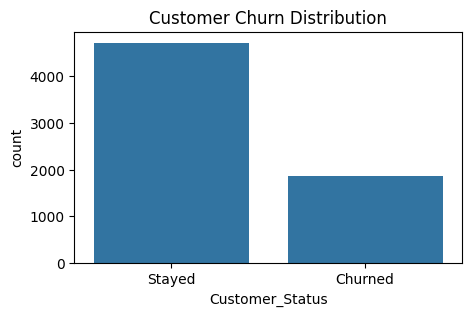

In [95]:
plt.figure(figsize=(5,3))
sns.countplot(x='Customer_Status',data=data)
plt.title('Customer Churn Distribution')
plt.show()

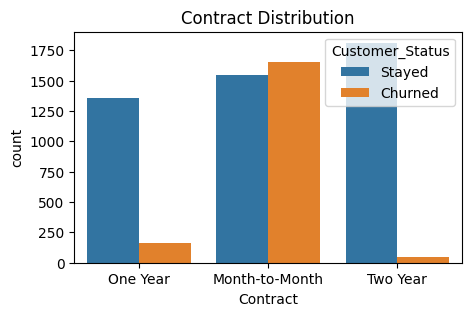

In [96]:
plt.figure(figsize=(5,3))
sns.countplot(x="Contract", hue = "Customer_Status", data=data)
plt.title('Contract Distribution')
plt.show()

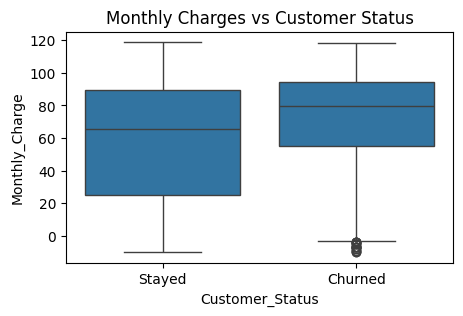

In [97]:
plt.figure(figsize=(5,3))
sns.boxplot(x="Customer_Status", y="Monthly_Charge", data=data)
plt.title("Monthly Charges vs Customer Status")
plt.show()

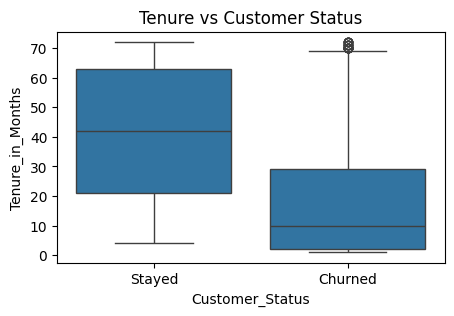

In [98]:
plt.figure(figsize=(5,3))
sns.boxplot(x="Customer_Status", y="Tenure_in_Months", data=data)
plt.title("Tenure vs Customer Status")
plt.show()

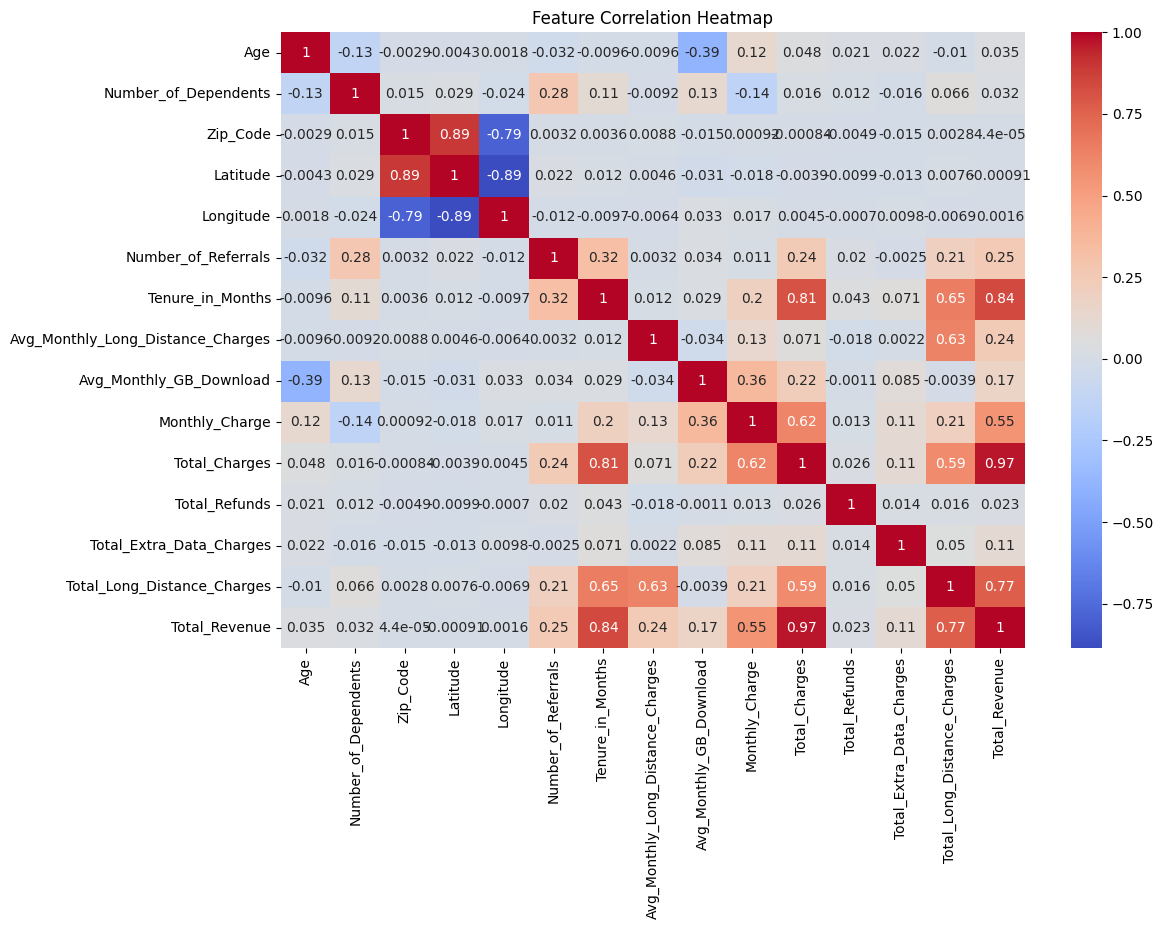

In [99]:
plt.figure(figsize=(12,8))
sns.heatmap(data[num_cols].corr(), annot=True,cmap ='coolwarm')
plt.title("Feature Correlation Heatmap")
#plt.xticks(rotation=45)
#plt.yticks(rotation=45)
plt.show ()

# 4. Feature Selection

In [100]:
data = data.drop(columns=drop_cols)

In [101]:
data.shape

(6589, 32)

# 5. Feature Engineering

In [102]:
data["Tenure Group"]= pd.cut(data["Tenure_in_Months"], bins =[0,12,24,48,72,120],labels = ["0-1yr", "1-2yr", "2-4yr", "4-6yr", "6+yr"])

In [103]:
# average spend per month
data["Revenue_Per_Month"] = data["Total_Revenue"] / (data["Tenure_in_Months"]+1)

In [104]:
data[["Tenure Group","Revenue_Per_Month"]].head()

,Tenure Group,Revenue_Per_Month
0,0-1yr,97.481000
1,0-1yr,61.028003
2,0-1yr,83.090002
3,1-2yr,114.250715
4,0-1yr,72.385002


# 6. Data Preprocessing and Train-Test Split

In [105]:
#  Define columns to encode 
col_to_encode = ["Gender","Married","City","Offer","Phone_Service","Multiple_Lines",
    "Internet_Service","Internet_Type","Online_Security","Online_Backup",
    "Device_Protection_Plan","Premium_Tech_Support",
    "Streaming_TV","Streaming_Movies","Streaming_Music",
    "Unlimited_Data","Contract","Paperless_Billing", "Payment_Method","Tenure Group"]


data["Tenure Group"] = data["Tenure Group"].astype(object).fillna("None")

#  Encode target variable 
data["Customer_Status"] = data["Customer_Status"].map({
    "Stayed": 0,
    "Churned": 1
})

#  Split BEFORE encoding — prevents data leakage 
X = data.drop("Customer_Status", axis=1)
y = data["Customer_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

#  Fit encoders on train only, transform both 
label_encoders = {}
for column in col_to_encode:
    le = LabelEncoder()
    X_train[column] = X_train[column].astype(str)
    le.fit(X_train[column])                       
    # Transform train
    X_train[column] = le.transform(X_train[column])

    # Transform test — handle unseen categories gracefully
    X_test[column] = X_test[column].astype(str).apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    X_test[column] = le.transform(X_test[column])

    label_encoders[column] = le

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 5271
Test samples     : 1318


# 7. Model Training

In [ ]:
#Define model
rf_model = RandomForestClassifier()

param_grid ={
    'n_estimators' : [ 100,150,175,200 ],
    'max_depth' : [ None,10,20 ],
    'min_samples_split' : [ 2,5,10 ],
    'max_features' : [ 'sqrt', 'log2' ]

}
# Grid Search with cross-validation
grid_search = GridSearchCV(rf_model, param_grid,cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)


In [ ]:
#Best paramenters from grid search
best_params = grid_search.best_params_

#Retran model with best parameters
best_rf = RandomForestClassifier(**best_params)
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
import joblib

#  Save Model 1 (existing customers) 
joblib.dump(best_rf, "model1_existing_customers.pkl")
joblib.dump(label_encoders, "model1_label_encoders.pkl")

print("Model 1 saved successfully")

Model 1 saved successfully


# 8. Model Evaluation

In [ ]:
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))

Accuracy: 0.8619119878603946
Confusion Matrix: [[896  48]
 [134 240]]
Classification Report:               precision    recall  f1-score   support

           0       0.87      0.95      0.91       944
           1       0.83      0.64      0.73       374

    accuracy                           0.86      1318
   macro avg       0.85      0.80      0.82      1318
weighted avg       0.86      0.86      0.86      1318



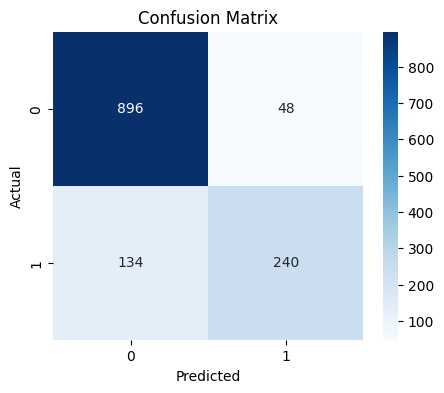

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 9. ROC-AUC Score and Curve

ROC-AUC Score: 0.9192720135049397


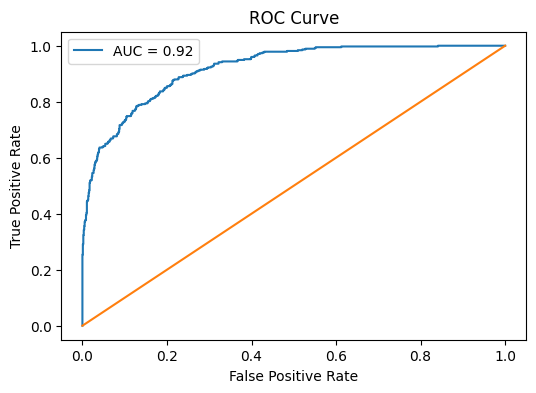

In [ ]:
y_prob = best_rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# 10. Feature Importance

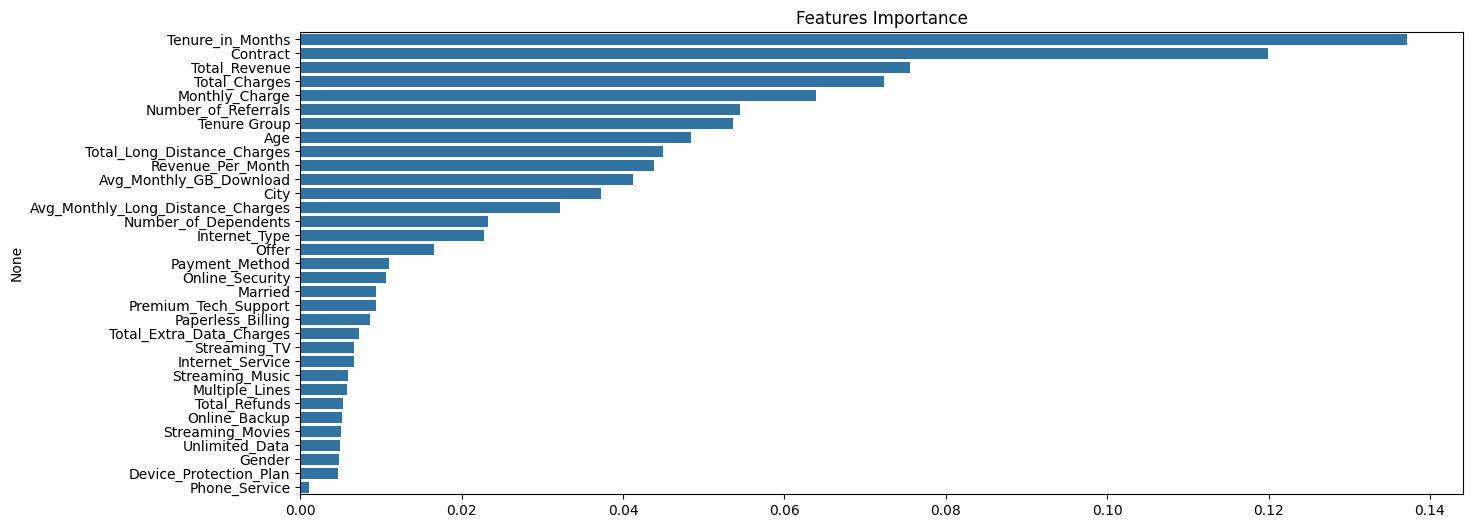

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
indices = importances.sort_values(ascending=False)

plt.figure(figsize=(15,6))
sns.barplot(x=indices.values, y=indices.index)
plt.title("Features Importance")
plt.show()

Insights from Feature Importance:

*   Customers with low tenure are more likely to churn.
*   Customers on month-to-month contracts have higher churn risk.
*   Higher monthly charges also contribute to churn probability.
*   Revenue and usage related features also influence customer retention.

# 11. Churn Prediction for New Customers

In [ ]:
# Read the data from specific sheet and covert into pandas df
new_data = pd.read_excel("dataset/Production Data.xlsx", sheet_name="vw_JoinData")
new_data.head()

,Customer_ID,Gender,Age,Married,Number_of_Dependents,City,Zip_Code,Latitude,Longitude,Number_of_Referrals,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,0021-IKXGC,Female,72,No,0,San Marcos,92078,33.119026,-117.166039,0,...,Bank Withdrawal,72.099998,72.099998,0.0,0,7.770000,79.870003,Joined,Others,Others
1,0030-FNXPP,Female,22,No,0,Keeler,93530,36.560497,-117.962463,0,...,Credit Card,19.850000,57.200001,0.0,0,9.360000,66.559998,Joined,Others,Others
2,0082-LDZUE,Male,54,No,0,Calistoga,94515,38.629620,-122.593216,0,...,Credit Card,44.299999,44.299999,0.0,0,42.950001,87.250000,Joined,Others,Others
3,0139-IVFJG,Female,19,Yes,0,Temecula,92592,33.507256,-117.029472,10,...,Bank Withdrawal,90.349998,190.500000,0.0,0,9.300000,199.800003,Joined,Others,Others
4,0178-CIIKR,Female,60,No,0,Crows Landing,95313,37.435665,-121.049057,0,...,Credit Card,19.950001,58.000000,0.0,0,8.070000,66.070000,Joined,Others,Others


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load new joiners ──────────────────────────────────────────────────────
raw_new_data = pd.read_excel("dataset/Production Data.xlsx", sheet_name="vw_JoinData")
original_data = raw_new_data.copy()

# ── 2. Define signup-time features only ─────────────────────────────────────
# These are features available on Day 1 — no tenure, no accumulated charges
signup_features = [
    "Gender", "Age", "Married", "Number_of_Dependents",
    "Contract", "Payment_Method", "Offer",
    "Internet_Type", "Monthly_Charge",
    "Phone_Service", "Internet_Service", "Paperless_Billing"
]

target = "Customer_Status"

In [ ]:
# 3. Build Model 2 training data from historical data 
# Use the same vw_ChurData but only signup-time columns

train_raw = pd.read_excel("dataset/Production Data.xlsx", sheet_name="vw_ChurData")

# Keep only signup features + target
model2_data = train_raw[signup_features + [target]].copy()

# Encode target
model2_data[target] = model2_data[target].map({"Stayed": 0, "Churned": 1})

# Check class balance
print("Class Distribution:")
print(model2_data[target].value_counts(normalize=True).round(3))

Class Distribution:
Customer_Status
0    0.716
1    0.284
Name: proportion, dtype: float64


In [ ]:
#4. Preprocess training data

# Fill nulls for categorical columns
cat_signup_cols = [
    "Gender", "Married", "Contract", "Payment_Method",
    "Offer", "Internet_Type", "Phone_Service",
    "Internet_Service", "Paperless_Billing"
]

for col in cat_signup_cols:
    model2_data[col] = model2_data[col].astype(str).str.strip()
    model2_data[col] = model2_data[col].replace({"nan": "None", "": "None"})

# Label encode categorical columns — fit on training data only
model2_encoders = {}
for col in cat_signup_cols:
    le = LabelEncoder()
    model2_data[col] = le.fit_transform(model2_data[col])
    model2_encoders[col] = le  # save encoder for applying on new data later

# Features and target split
X2 = model2_data[signup_features]
y2 = model2_data[target]

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"Training samples: {X2_train.shape[0]}")
print(f"Test samples:     {X2_test.shape[0]}")

Training samples: 5271
Test samples:     1318


In [ ]:
# 5. Train Model 2 

model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',   # handles class imbalance automatically
    random_state=42
)

model2.fit(X2_train, y2_train)

# Evaluate on test set
y2_pred = model2.predict(X2_test)
y2_prob = model2.predict_proba(X2_test)[:, 1]

print("── Model 2 Evaluation (Signup-Time Features) ──")
print(classification_report(y2_test, y2_pred))
print(f"ROC-AUC Score: {roc_auc_score(y2_test, y2_prob):.3f}")

── Model 2 Evaluation (Signup-Time Features) ──
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       944
           1       0.63      0.80      0.70       374

    accuracy                           0.81      1318
   macro avg       0.77      0.81      0.78      1318
weighted avg       0.83      0.81      0.81      1318

ROC-AUC Score: 0.885


In [ ]:
# ── Save Model 2 (new joiners) 
joblib.dump(model2, "model2_new_joiners.pkl")
joblib.dump(model2_encoders, "model2_label_encoders.pkl")

print("Model 2 saved successfully")

Model 2 saved successfully


In [ ]:
#  6. Apply Model 2 on new joiners

new_data = original_data[signup_features].copy()

# Apply same preprocessing
for col in cat_signup_cols:
    new_data[col] = new_data[col].astype(str).str.strip()
    new_data[col] = new_data[col].replace({"nan": "None", "": "None"})
    
    le = model2_encoders[col]
    known_classes = set(le.classes_)
    
    # Get most frequent class from training data as fallback
    # instead of "None" which may not exist in encoder
    fallback = model2_data[col].mode()[0]  # most frequent encoded value
    
    # For unseen categories, map to most frequent known class
    def safe_encode(x):
        # reverse map fallback integer back to string label
        fallback_label = le.classes_[fallback]
        return x if x in known_classes else fallback_label
    
    new_data[col] = new_data[col].apply(safe_encode)
    new_data[col] = le.transform(new_data[col])

# Predict
pred_probs = model2.predict_proba(new_data)[:, 1]

In [ ]:
#  7. Risk tier instead of binary prediction 

def assign_risk_tier(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.45:
        return "Medium Risk"
    else:
        return "Low Risk"

original_data["Churn_Probability"] = (pred_probs * 100).round(2)
original_data["Churn_Risk"]        = pd.Series(pred_probs).apply(assign_risk_tier).values

# 8. Summary 
print("── Predicted Risk Distribution ──")
print(original_data["Churn_Risk"].value_counts())
print()
print(f"High Risk   : {(original_data['Churn_Risk'] == 'High Risk').sum()}")
print(f"Medium Risk : {(original_data['Churn_Risk'] == 'Medium Risk').sum()}")
print(f"Low Risk    : {(original_data['Churn_Risk'] == 'Low Risk').sum()}")

── Predicted Risk Distribution ──
Churn_Risk
Medium Risk    158
High Risk      156
Low Risk       140
Name: count, dtype: int64

High Risk   : 156
Medium Risk : 158
Low Risk    : 140


In [ ]:
# ── 9. Save output for Power BI ──────────────────────────────────────────────

output_cols = [
    "Customer_ID", "Gender", "Age", "Married", "Number_of_Dependents",
    "City", "Contract", "Payment_Method", "Offer",
    "Internet_Type", "Phone_Service", "Internet_Service",
    "Paperless_Billing", "Monthly_Charge",
    "Churn_Probability", "Churn_Risk"
]

final_output = original_data[output_cols].copy()

# Clean column names — remove spaces for Power BI compatibility
final_output.columns = final_output.columns.str.replace(" ", "_")

# Sort by highest churn probability first — most at-risk on top
final_output = final_output.sort_values("Churn_Probability", ascending=False).reset_index(drop=True)

# Add a rank column — useful for Power BI top N filtering
final_output.insert(0, "Risk_Rank", range(1, len(final_output) + 1))
final_output["Offer"] = final_output["Offer"].fillna("No Offer")

# Summary before saving
print("── Output Summary ──")
print(f"Total New Joiners    : {len(final_output)}")
print(f"High Risk            : {(final_output['Churn_Risk'] == 'High Risk').sum()}")
print(f"Medium Risk          : {(final_output['Churn_Risk'] == 'Medium Risk').sum()}")
print(f"Low Risk             : {(final_output['Churn_Risk'] == 'Low Risk').sum()}")
print()
print("── Sample Output (Top 5 High Risk) ──")
print(final_output.head())

# Save to Excel
final_output.to_excel("Customer_Churn_Predicted.xlsx", index=False)
print("Saved to Customer_Churn_Predicted.xlsx")

── Output Summary ──
Total New Joiners    : 454
High Risk            : 156
Medium Risk          : 158
Low Risk             : 140

── Sample Output (Top 5 High Risk) ──
   Risk_Rank Customer_ID  Gender  Age Married  Number_of_Dependents  \
0          1  3411-WLRSQ  Female   80     Yes                     0   
1          2  3295-YVUSR    Male   73      No                     0   
2          3  9605-WGJVW  Female   69      No                     0   
3          4  3566-HJGPK    Male   50      No                     0   
4          5  7245-NIIWQ  Female   53      No                     0   

             City        Contract   Payment_Method     Offer Internet_Type  \
0     Los Angeles  Month-to-Month  Bank Withdrawal   Offer E   Fiber Optic   
1        Glendale  Month-to-Month     Mailed Check  No Offer   Fiber Optic   
2        Stockton  Month-to-Month  Bank Withdrawal  No Offer   Fiber Optic   
3  Woodland Hills  Month-to-Month     Mailed Check   Offer E           DSL   
4         Fello

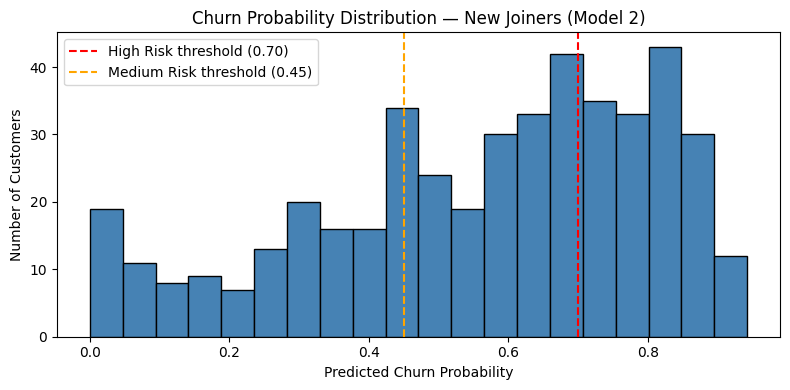

In [ ]:
# ── Probability Distribution of New Joiners 
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(pred_probs, bins=20, color='steelblue', edgecolor='black')
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Churn Probability Distribution — New Joiners (Model 2)")
plt.axvline(x=0.70, color='red', linestyle='--', label='High Risk threshold (0.70)')
plt.axvline(x=0.45, color='orange', linestyle='--', label='Medium Risk threshold (0.45)')
plt.legend()
plt.tight_layout()
plt.show()

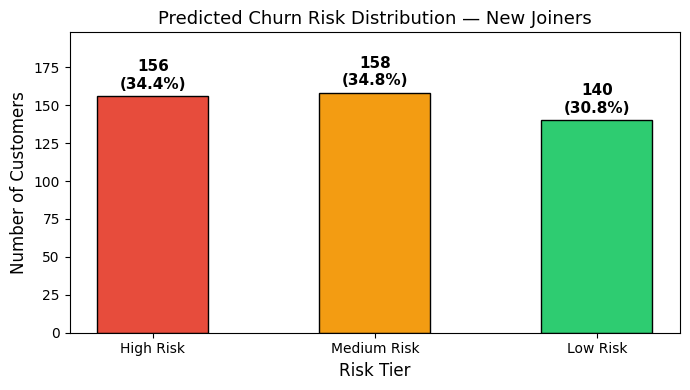

In [ ]:
# Risk Tier Distribution Chart 

risk_counts = original_data["Churn_Risk"].value_counts()

# Define order and colors
risk_order  = ["High Risk", "Medium Risk", "Low Risk"]
risk_colors = ["#e74c3c", "#f39c12", "#2ecc71"]

# Reindex to enforce order
risk_counts = risk_counts.reindex(risk_order)

plt.figure(figsize=(7, 4))
bars = plt.bar(risk_counts.index, risk_counts.values, color=risk_colors, edgecolor='black', width=0.5)

# Add count + percentage labels on top of each bar
total = risk_counts.sum()
for bar, count in zip(bars, risk_counts.values):
    pct = count / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{count}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.xlabel("Risk Tier", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.title("Predicted Churn Risk Distribution — New Joiners", fontsize=13)
plt.ylim(0, risk_counts.max() + 40)
plt.tight_layout()
plt.show()

# 12. Conclusion

This project built a complete end-to-end customer churn analysis pipeline
for a telecom company, covering data engineering, machine learning, and
business intelligence.

### What was built

**SQL Layer**
- Null value audit across all 38 columns
- Null replacement with business-appropriate defaults
- Staging to production table pipeline
- Separate views for churned/stayed vs new joiner customers

**Python Layer — Model 1 (Existing Customers)**
- Exploratory data analysis on 7,000+ customers
- Feature engineering — Tenure Group and Revenue Per Month
- Random Forest model with GridSearchCV hyperparameter tuning
- Achieved ~86% accuracy and high ROC-AUC score
- Key churn drivers identified — tenure, contract type, monthly charges

**Python Layer — Model 2 (New Joiners)**
- Identified critical limitation of Model 1 — distribution shift
  on new customers due to tenure and revenue bias
- Built a separate model using only signup-time features available
  on Day 1 — contract, payment method, internet type, monthly charge,
  demographics
- Produced realistic risk distribution:
  - High Risk  : 156 customers (34.4%)
  - Medium Risk : 158 customers (34.8%)
  - Low Risk   : 140 customers (30.8%)

**Power BI Layer**
- Page 1 — Historical churn analysis dashboard
  showing churn by contract, tenure, age, internet type,
  payment method, city and services
- Page 2 — Prediction dashboard showing risk tiers,
  churn probability distribution, high risk customer table
  sorted by Risk_Rank for actionable retention targeting

---

### Key Insights

1. Month-to-Month contracts drive the highest churn (45.84%)
2. Fiber Optic customers churn more than any other internet type (40.72%)
3. Competitor switching is the #1 churn reason (841 customers)
4. Early tenure customers (<6 months) are the most vulnerable segment
5. Mailed Check payment method correlates with highest churn rate (36.88%)

---

### What makes this project different

Most churn models apply a single model to all customers regardless
of their tenure stage. This project identified that new joiners and
existing customers have fundamentally different feature distributions
and built a two-model architecture to handle each segment appropriately.

This approach more closely mirrors real-world production ML systems
where separate models handle different customer lifecycle stages.

---

### Future Improvements

1. Retrain Model 2 every 6 months as new joiner outcome data accumulates
2. Add SHAP values for individual customer level explainability
3. Build a real-time scoring API using Flask or FastAPI
4. Incorporate external data — competitor pricing, market trends
5. Conduct A/B testing on retention offers to validate model ROI

# 13. Business Recommendations

### Key Findings from Analysis

#### Finding 1 — Contract Type is the Strongest Churn Driver
- Month-to-Month customers have 45.84% churn rate vs 2.55% for Two Year contracts
- Average churn probability for Month-to-Month new joiners is 62% vs 7% for Two Year

**Recommendation:**
Offer new joiners a discounted annual contract at signup.
Example: "Switch to One Year plan and get 15% off your first 3 months"
Target: Convert at least 30% of Month-to-Month new joiners to annual contracts

---

#### Finding 2 — Fiber Optic Customers Churn the Most
- Fiber Optic has the highest churn rate among all internet types (40.72% from Page 1)
- Majority of Top 5 highest risk new joiners are on Fiber Optic

**Recommendation:**
Investigate Fiber Optic service quality — speed complaints, outages, pricing
Offer Fiber Optic customers a free Premium Tech Support upgrade for 3 months
This directly addresses the Dissatisfaction churn category (321 customers)

---

#### Finding 3 — Competitor is #1 Churn Reason (841 customers)
- Competitor related churn accounts for the largest churn category
- These customers are leaving for better offers elsewhere

**Recommendation:**
Launch a proactive retention offer for High Risk customers before they switch
Example: "We noticed you've been with us for X months — here's an exclusive loyalty offer"
Target customers with Churn_Probability >= 70% and Tenure < 24 months

---

#### Finding 4 — Mailed Check Payment Method has Highest Churn (36.88%)
- Customers paying by Mailed Check are least engaged digitally
- They are also least likely to be on auto-renewal

**Recommendation:**
Incentivize switch to automatic payment methods
Example: "Set up auto-pay and get $5 off your next bill"
This reduces both churn risk and payment default risk

---

#### Finding 5 — Senior Customers (>65) Need Attention
- Age group >65 shows 73.33% Medium+High risk in new joiners (Page 2)
- They may need more support and handholding

**Recommendation:**
Assign a dedicated customer success call for new joiners above age 60
Offer Premium Tech Support free for first 3 months for this segment

---

### Prioritized Action Plan

| Priority | Segment | Action | Expected Impact |
|---|---|---|---|
| 1 | Month-to-Month new joiners | Offer discounted annual contract | Reduce high risk count by ~30% |
| 2 | High Risk Fiber Optic customers | Free tech support upgrade | Address dissatisfaction churn |
| 3 | Churn_Probability >= 70% | Proactive loyalty offer | Retain before competitor switch |
| 4 | Mailed Check customers | Incentivize auto-pay switch | Reduce disengagement |
| 5 | New joiners age >60 | Dedicated success call | Improve early experience |

---

### Model Limitations and Future Work

1. Model 2 is trained on historical churn patterns — as more new joiner data
   becomes available over time the model should be retrained every 6 months

2. External factors like competitor pricing and market conditions are not
   captured in the current dataset

3. A/B testing should be conducted on retention offers to measure actual
   impact vs model predictions